In [1]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [195]:
df = pd.read_pickle('../../all_fluxes_new.pkl')

In [186]:
df.columns

Index(['id', 'tile_index', 'ra', 'dec', 'FWHM', 'point_source_probability_mer',
       'weight_size', 'CFIS-U', 'CFIS-U_sigma', 'NIR-Y', 'NIR-Y_sigma',
       'CFIS-R', 'CFIS-R_sigma', 'NIR-J', 'NIR-J_sigma', 'NIR-H',
       'NIR-H_sigma', 'WISHES-Z', 'WISHES-Z_sigma', 'PANSTARRS-I',
       'PANSTARRS-I_sigma', 'WISHES-G', 'WISHES-G_sigma', 'VIS', 'VIS_sigma',
       'DES-Z', 'DES-Z_sigma', 'DES-I', 'DES-I_sigma', 'DES-G', 'DES-G_sigma',
       'DES-R', 'DES-R_sigma'],
      dtype='str')

In [187]:
DES = True

In [208]:
if DES:
    bands = ['DES-G','DES-R','DES-I','DES-Z','VIS','NIR-Y','NIR-J','NIR-H']
else:
    bands = ['CFIS-U','WISHES-G','CFIS-R','PANSTARRS-I','WISHES-Z','VIS','NIR-Y','NIR-J','NIR-H']

# positive fluxes only
for b in bands:
    df = df[df[b]/df[f'{b}_sigma'] > 10]

In [203]:
for b in bands:
    df[f'{b}_mag'] = -2.5*np.log10(df[b])

In [209]:
if DES:
    df['g_r'] = df['DES-G_mag'] - df['DES-R_mag']
    df['r_i'] = df['DES-R_mag'] - df['DES-I_mag']
    df['i_z'] = df['DES-I_mag'] - df['DES-Z_mag']
    df['z_VIS'] = df['DES-Z_mag'] - df['VIS_mag']
    df['VIS_Y'] = df['VIS_mag'] - df['NIR-Y_mag']
    df['Y_J'] = df['NIR-Y_mag'] - df['NIR-J_mag']
    df['Y_H'] = df['NIR-Y_mag'] - df['NIR-H_mag']
    df['J_H'] = df['NIR-J_mag'] - df['NIR-H_mag']
    df['g_H'] = df['DES-G_mag'] - df['NIR-H_mag']
else:
    df['u_g'] = df['CFIS-U_mag'] - df['WISHES-G_mag']
    df['g_r'] = df['WISHES-G_mag'] - df['CFIS-R_mag']
    df['r_i'] = df['CFIS-R_mag'] - df['PANSTARRS-I_mag']
    df['i_z'] = df['PANSTARRS-I_mag'] - df['WISHES-Z_mag']
    df['z_VIS'] = df['WISHES-Z_mag'] - df['VIS_mag']
    df['VIS_Y'] = df['VIS_mag'] - df['NIR-Y_mag']
    df['Y_J'] = df['NIR-Y_mag'] - df['NIR-J_mag']
    df['Y_H'] = df['NIR-Y_mag'] - df['NIR-H_mag']
    df['J_H'] = df['NIR-J_mag'] - df['NIR-H_mag']
    df['u_H'] = df['CFIS-U_mag'] - df['NIR-H_mag']

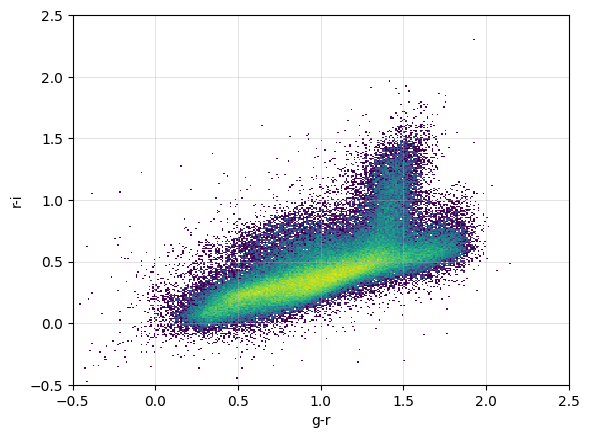

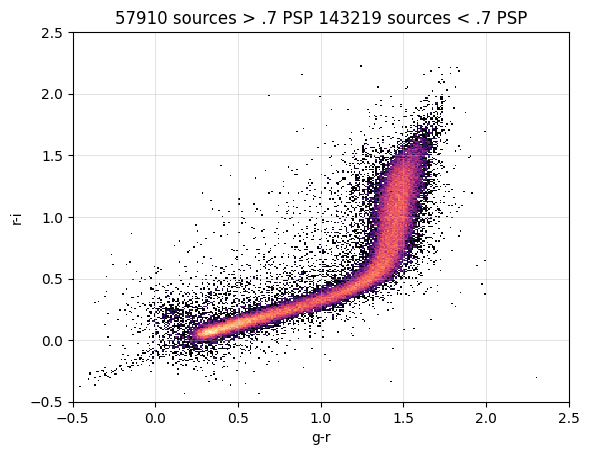

In [211]:
xmin,xmax = -.5, 2.5
ymin,ymax = -.5, 2.5
n_bins= 300
x_bins = np.linspace(xmin, xmax, n_bins+1)
y_bins = np.linspace(ymin, ymax, n_bins+1)
bins = (x_bins, y_bins)
x_color = 'g_r'
y_color = 'r_i'
mask = df['point_source_probability_mer'] <=.7
H, xedges, yedges = np.histogram2d(
    df[x_color][mask], df[y_color][mask], bins=bins)
plt.pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='viridis'
)
plt.grid()
plt.xlabel(x_color.replace('_', '-'))
plt.ylabel(y_color.replace('_', '-'))
plt.show()
mask = df['point_source_probability_mer'] > .7
H, xedges, yedges = np.histogram2d(
    df[x_color][mask], df[y_color][mask], bins=bins)
plt.pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='magma'
)
plt.title(f'{np.sum(mask)} sources > .7 PSP {np.sum(~mask)} sources < .7 PSP')
plt.grid()
plt.xlabel(x_color.replace('_', '-'))
plt.ylabel(y_color.replace('_', '-'))
plt.show()

In [212]:
if DES:
    features = ['g_r', 'r_i',
                'i_z', 'z_VIS', 'VIS_Y', 'Y_J', 'Y_H',
        'g_H','J_H'
    ]
else:
    features = ['u_g', 'g_r', 'r_i',
                'VIS_Y', 'Y_J', 'Y_H',
        'u_H','J_H'
    ]

X = df[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]

In [213]:
print(len(X), 'sources')

201129 sources


In [130]:
Xn = StandardScaler().fit_transform(X)

In [131]:
idx = np.random.choice(
    Xn.shape[0],
    size=154269,
    replace=False
)

X_subset = Xn[idx]
X_subset = Xn

In [132]:
embedding = umap.UMAP(
    n_neighbors=200,
    min_dist=0.05,
    n_components=5
).fit_transform(X_subset)

In [133]:
clusterer = HDBSCAN(
    min_cluster_size=200,
    min_samples=100
)

labels = clusterer.fit_predict(embedding)
print(np.unique(labels, return_counts=True))

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


(array([0, 1]), array([68934, 85335]))


In [134]:
embedding_2d = umap.UMAP(
    n_neighbors=200,
    min_dist=0.05
).fit_transform(X_subset)

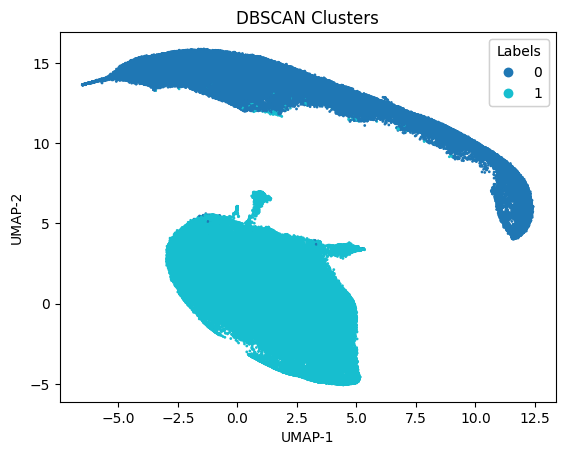

In [135]:
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10'
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("DBSCAN Clusters")
# Create legend entries from the scatter plot
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)

plt.show()

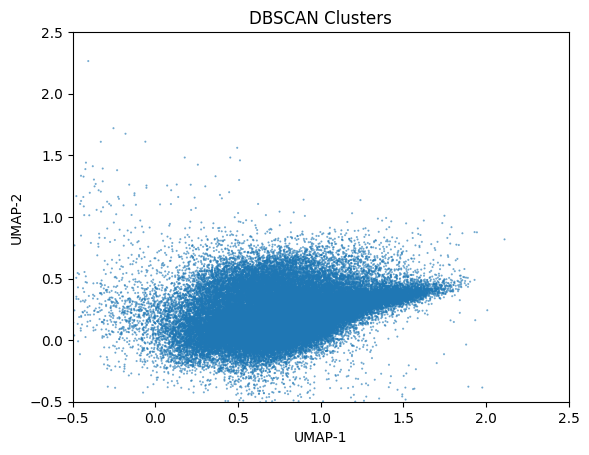

In [121]:
mask = labels == 5

scatter = plt.scatter(
    X[idx][:,1][mask],
    X[idx][:,2][mask],
    c=labels[mask],
    s=1,
    cmap='tab10',
    marker='o',
    linewidths=0.5,
    alpha=0.5,
    label='DBSCAN'
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("DBSCAN Clusters")
plt.xlim(-.5, 2.5)
plt.ylim(-.5, 2.5)
plt.show()

In [136]:
group_mask = labels == 0
group = X_subset[group_mask]
other = X_subset[~group_mask]
group_mean = group.mean(axis=0)
rest_mean = other.mean(axis=0)

global_std = X_subset.std(axis=0)

delta = (group_mean - rest_mean) / global_std

importance = pd.Series(
    delta,
    index=features
).sort_values(key=np.abs, ascending=False)

print(importance)

J_H     -1.601418
Y_H     -1.506727
Y_J     -1.216843
u_g      1.137072
VIS_Y   -0.885518
r_i     -0.251985
g_r     -0.218083
u_H     -0.025472
dtype: float64


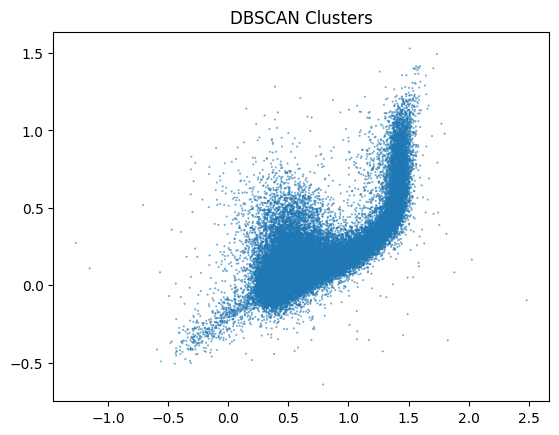

In [179]:
mask = (labels == 0)
scatter = plt.scatter(
    X[idx][:,1][mask],
    X[idx][:,2][mask],
    c=labels[mask],
    s=1,
    cmap='tab10',
    marker='o',
    linewidths=0.5,
    alpha=0.5,
    label='DBSCAN'
)

plt.title("DBSCAN Clusters")
# plt.xlim(-1.5, 2)
# plt.ylim(-1, 1)
plt.show()